# Training Models

This is a jupyter note that contains code example of fourth chapter of the book.

You won't find here detailed explanation of the contents. This notebook contains **general info** and **code examples**.
See detailed notes about all conception on my cloud obsidian vault.

Importing packages...

In [59]:
from copy import deepcopy

import random
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.pyplot import title

from sklearn.preprocessing import add_dummy_feature, PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, SGDRegressor, Ridge, Lasso, LogisticRegression
from sklearn.model_selection import learning_curve, ShuffleSplit, StratifiedShuffleSplit
from sklearn.pipeline import make_pipeline
from sklearn.metrics import root_mean_squared_error
from sklearn import datasets as sk_datasets

# The Normal Equation

Let's generate some linear data and plot it.

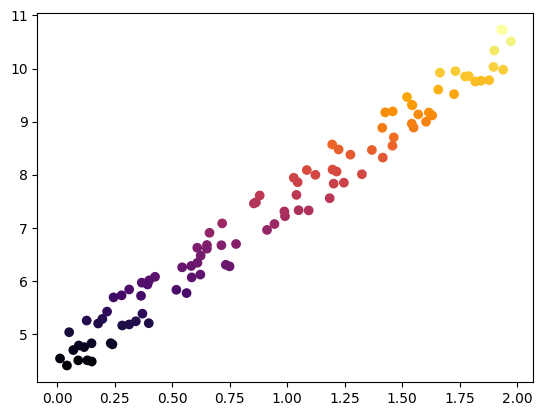

In [2]:
np.random.seed(42)

n = 100
X = 2 * np.random.rand(n, 1) # Column vector
y = 4 + 3 * X + np.random.rand(n, 1) # Column vector as well

plt.scatter(X, y, c=y, cmap="inferno")
plt.show()

Now, let's apply **The Normal Equation**, to get first $\theta$ value for linear regression model.

 > As we know, $x0$ feature at the bias $\theta$ is always equals 1, that's why we need to add dummy feature to each instance that equals to 1

In [3]:
X_d = add_dummy_feature(X=X)
X_d[:3]

array([[1.        , 0.74908024],
       [1.        , 1.90142861],
       [1.        , 1.46398788]])

Now, we can apply our **Normal Equation**.
Formula:


In [4]:
if not np.linalg.det(X_d.T @ X_d) <= 0:
    theta_0 = np.linalg.inv(X_d.T @ X_d) @ X_d.T @ y
    print(theta_0)
else:
    print("Matrix determinant is zero, could not inverse it")

[[4.51359766]
 [2.98323418]]


We got our parameters, now we can train our simple **Linear Regression** model!

In [5]:
X_new = np.array([[0], [2]])
X_new_d = add_dummy_feature(X=X_new)
y_predictions = X_new_d @ theta_0
y_predictions

array([[ 4.51359766],
       [10.48006601]])

Now, when we know 2 predictions, we can plot a line through two predictions dots. That is our **Linear Regression Predictions**.

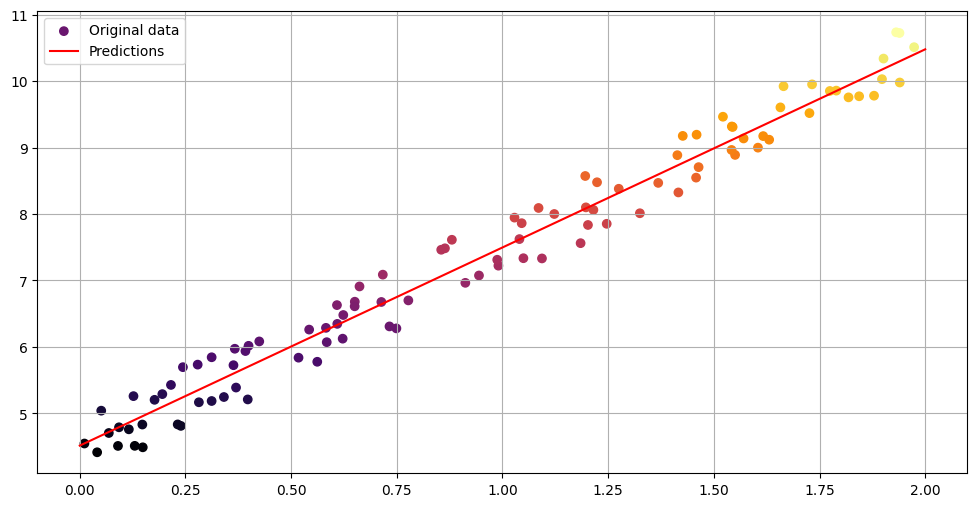

In [6]:
fig, ax = plt.subplots(figsize=(12, 6))

plt.scatter(X, y, c=y, cmap="inferno", label="Original data")
plt.plot(X_new, y_predictions, color="red", label="Predictions")
plt.grid(True)
plt.legend()
plt.show()

Let's try to use **SKlearn** Linear Regression model, the approach is relatively straightforward.

In [7]:
lin_reg = LinearRegression()
lin_reg.fit(X, y)

lin_reg.intercept_, lin_reg.coef_

(array([4.51359766]), array([[2.98323418]]))

As you can see, the bias and $\theta$ parameters are the same as ours!

In [8]:
lin_reg.predict(X_new)

array([[ 4.51359766],
       [10.48006601]])

Since The Normal Equation isn't universal, because we can't take inverted matrix when the matrix determinant is 0 and the matrix isn't squared. All model are using **The Least Squares Approach**. Formula:

Where + is pseudoinverse matrix. This matrix is computed by using **SVD** _(Singular Value Decomposition)_.

In [9]:
theta_best_svd, residuals, rank, s = np.linalg.lstsq(X_d, y, rcond=1e-6)
theta_best_svd

array([[4.51359766],
       [2.98323418]])

Using the formula, we can manually compute the parameters.

In [10]:
np.linalg.pinv(X_d) @ y

array([[4.51359766],
       [2.98323418]])

The Time complexity of the **Normal Equation** is about $O(n^{2.4})$ to $O(n^3)$, while the SVD approach is about $O(n^2)$. The prediction time is linear.

# Gradient Descent

Gradient Descent is another way to train Linear Regression and an optimal approach to optimize and find optimal solution to wide range of problems.

In [11]:
eta = 0.1
n_epochs = 1000
m = len(X_d)

np.random.seed(42)
theta = np.random.rand(2, 1)

for _ in range(n_epochs):
    gradients = (2 / m) * X_d.T @ (X_d @ theta - y)
    theta = theta - eta * gradients

theta

array([[4.51359766],
       [2.98323418]])

Exactly what out **Normal Equation** found! Now, we can plot each training step, to see how parameters $\eta$ and **n_epoch** are influencing on our linear regression line.

> Each iteration over training set called **Epoch**

In [12]:
def plot_gradient_descent(eta: int, n_epochs: int, X: np.array, best_theta: np.array = None):
    thetas = []
    theta = np.random.rand(2, 1)

    for _ in range(n_epochs):
        gradients = (2 / m) * X_d.T @ (X_d @ theta - y)
        theta = theta - eta * gradients
        thetas.append(theta)

    X_model_line = np.array([[0], [2]])

    for i, theta in enumerate(thetas):
        predictions = add_dummy_feature(X=X_model_line) @ theta

        plt.plot(X_model_line, predictions, color="blue", alpha=1/n_epochs*i)

    if best_theta is not None:
        plt.plot(X_model_line, add_dummy_feature(X=X_model_line) @ best_theta, color="red")

    plt.show()

Now we can plot our gradient descent process and see how our hyperparameters $\eta$ and **n_epochs** affect $\theta$ parameters selection.

If learning step is too high - we just jump over to global MSE minimum.

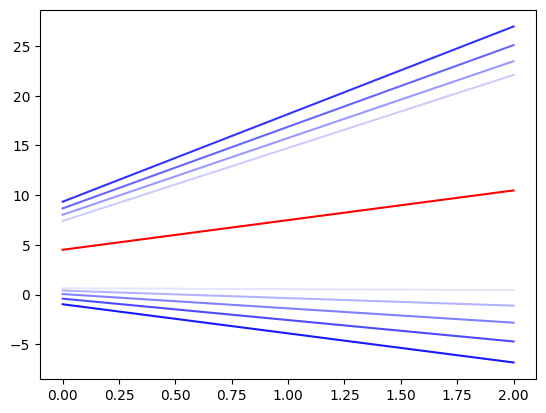

In [13]:
plot_gradient_descent(0.5, 10, X_d, best_theta=theta)


If we set reasonable learning step - our thetas would be near the global minimum of the MSE.

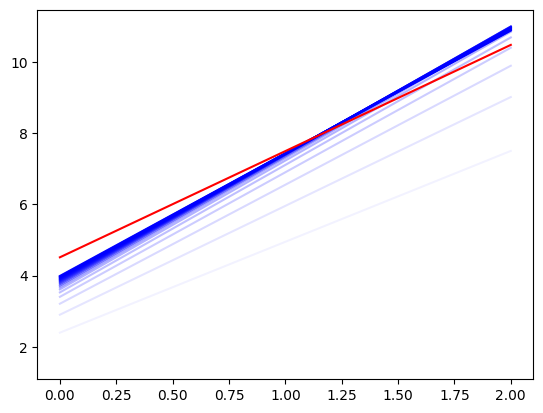

In [14]:
plot_gradient_descent(0.1, 20, X_d, best_theta=theta)

At to small learning step - we might not reach the MSE minimum.

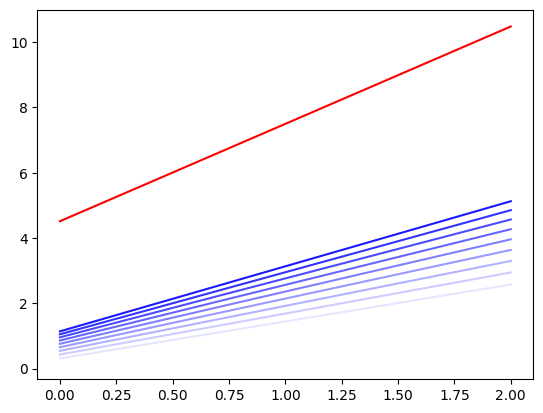

In [15]:
plot_gradient_descent(0.01, 10, X_d, best_theta=theta)

# Stochastic Gradient Descent

Now, lets implement stochastic gradient descent, where we pick only random entry from the training set.

[[4.39008808]
 [3.03586855]]


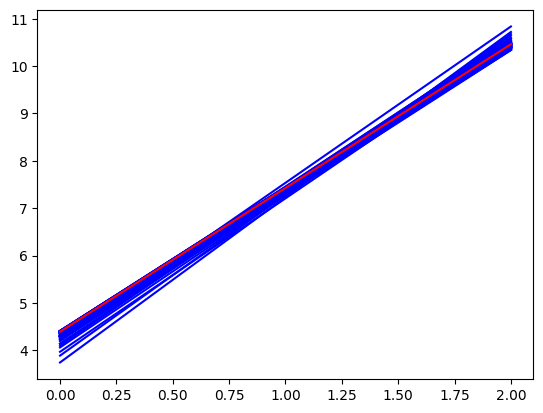

In [16]:
n_epochs = 100
m=10
t0, t1 = 5, 50

def learning_schedule(t):
    return t0 / (t + t1)

theta = np.random.rand(2, 1)

for epoch in range(n_epochs):
    for iteration in range(m):
        random_index = np.random.randint(0, m)
        xi = X_d[random_index : random_index + 1]
        yi = y[random_index : random_index + 1]

        gradients = 2 * xi.T @ (xi @ theta - yi)
        eta = learning_schedule(epoch * m + iteration)
        theta = theta - eta * gradients

    X_plot = np.array([[0], [2]])
    plt.plot(X_plot, add_dummy_feature(X_plot) @ theta, color="blue")

print(theta)
plt.plot(X_plot, add_dummy_feature(X_plot) @ theta, color="red")
plt.show()

Pretty accurate results! But also pretty irregular jumps.

In **SKLearn**, you can manually use the SGD using **SGDRegressor** class
- max_iter is a number of epochs
- tol is a value of epsilon neighborhood at the point where derivative of the cost function is 0, when SGD get into the epsilon neighborhood - learning stops
- eta0 is a starting learning rate
- n_ite_no_change is a learning_schedule that tells after what amount of epochs model should switch learning rate

In [17]:
sgd_reg = SGDRegressor(max_iter=1000, tol=1e-5, eta0=0.01, n_iter_no_change=100, penalty=None)
sgd_reg.fit(X, y.ravel())

,loss,'squared_error'
,penalty,None
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,1e-05
,shuffle,True
,verbose,0
,epsilon,0.1
,random_state,None


In [18]:
print(f"SGD - {sgd_reg.intercept_}, {sgd_reg.coef_}")
print(f"TNE thetas - {theta_best_svd}")

SGD - [4.50635602], [2.98973698]
TNE thetas - [[4.51359766]
 [2.98323418]]


# Mini-Batch Gradient Descent

Unlike BGD and SGD, mini-batch works using only certain batches of the dataset. For example if we had 10 000 instances, at each iteration we would take only 100 instances

In [19]:
m = len(X_d[:])
n_batches = 10
n_epochs = 100

eta = 0.01

theta = np.random.rand(2, 1)

for epoch in range(n_epochs):
    for iteration in range(n_batches):
        start_idx, end_idx = (n_batches * iteration), int((n_batches * iteration) + (m / n_batches))
        X_batch = X_d[start_idx : end_idx]
        y_batch = y[start_idx : end_idx]

        gradients = (2/(m / n_batches)) * (X_batch.T @ (X_batch @ theta - y_batch))
        theta = theta - eta * gradients

theta

array([[4.48176217],
       [3.01454912]])

# Gradient Descents figure

When we have implementations of every gradient descent, we can plot their path using $\theta$-s on each epoch

Firstly, lets wrap out implementation in convenient functions

In [20]:
def plot_batch_gd(X: np.array, y: np.array, eta: float | int = 0.01, n_epochs: int = 1000):
    """X array must already contain dummy feature for theta_0"""

    np.random.seed(42)

    theta_X = []
    theta_y = []

    m = len(X[:])
    theta = np.random.rand(2, 1)

    for _ in range(n_epochs):
        gradients = (2 / m) * X.T @ (X @ theta - y)
        theta = theta - eta * gradients

        theta_X.append(theta[0])
        theta_y.append(theta[1])

    plt.plot(theta_X, theta_y, label="Batch Gradient Descent", color="blue")

def plot_stochastic_gd(X: np.array, y: np.array, eta: float | int = 0.01, n_epochs: int = 1000):
    """X array must already contain dummy feature for theta_0"""

    np.random.seed(42)

    theta_X = []
    theta_y = []

    m = len(X[:])
    theta = np.random.rand(2, 1)

    for epoch in range(n_epochs):
        for iteration in range(m):
            random_index = np.random.randint(0, m)

            random_X = X[random_index : random_index + 1]
            random_y = y[random_index : random_index + 1]

            gradients = 2 * random_X.T @ (random_X @ theta - random_y)
            theta = theta - eta * gradients

            theta_X.append(theta[0])
            theta_y.append(theta[1])

    plt.plot(theta_X, theta_y, label="Stochastic Gradient Descent", color="red")

def plot_mini_batch_gd(X: np.array, y: np.array, eta: float | int = 0.01, n_epochs: int = 1000, n_batches: int = 10):
    """X array must already contain dummy feature for theta_0"""

    np.random.seed(42)

    theta_X = []
    theta_y = []

    batch_size = len(X[:]) / n_batches
    theta = np.random.rand(2, 1)

    for epoch in range(n_epochs):
        for iteration in range(n_batches):
            start_idx = int(iteration * batch_size)
            end_idx = int(start_idx + batch_size)

            X_batch = X[start_idx : end_idx]
            y_batch = y[start_idx : end_idx]

            gradients = (2/(m / n_batches)) * (X_batch.T @ (X_batch @ theta - y_batch))
            theta = theta - eta * gradients

            theta_X.append(theta[0])
            theta_y.append(theta[1])

    plt.plot(theta_X, theta_y, label="Mini-Batch Gradient Descent", color="yellow")


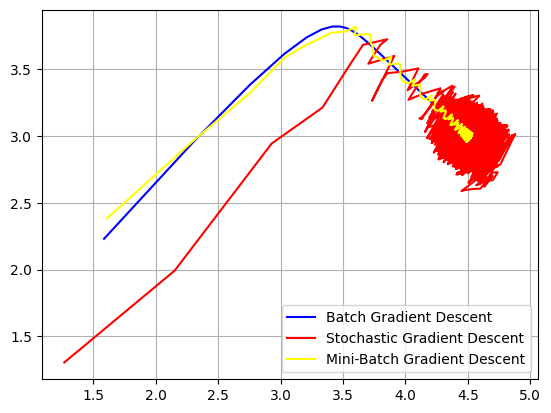

In [21]:
plot_batch_gd(X_d, y, n_epochs=100, eta=0.1) # Blue
plot_stochastic_gd(X_d, y, n_epochs=100, eta=0.1)
plot_mini_batch_gd(X_d, y, n_epochs=100, eta=0.1)

plt.legend()
plt.grid(True)
plt.show()

 There, you can **see** difference between each approach. As we can see, stochastic gradient descent is jumping alot at the mean squared error function global minimum, while mini-batch GD jumps are predictable, because we use static batch size.

# Polynomial Regression

When our data is more complex that a straight line, we still use linear model. A simple way to do this - to add powers of each feature as a new feature: $\theta_{powered} = \theta_i^n$

Firstly, let's generate some non linear data using canon quadratic equation $y = ax^2 + bx + c$ with some noise

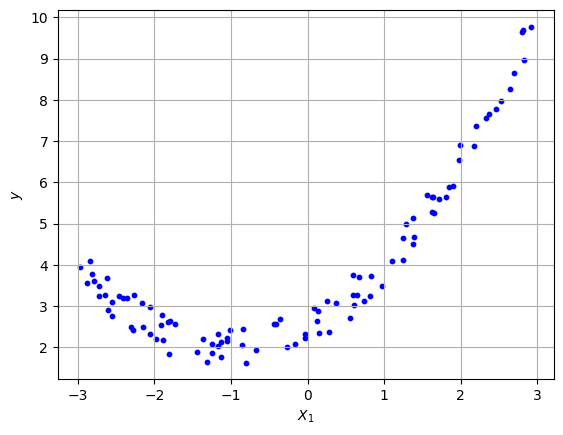

In [22]:
m = 100
X = 6 * np.random.rand(m, 1) - 3
y = 0.5 * X ** 2 + X + 2 + np.random.rand(m, 1)

plt.scatter(X, y, color="blue", s=10)
plt.grid(True)
plt.xlabel("$X_1$")
plt.ylabel("$y$")
plt.show()

Since the straight line won't fit non-linear data properly. So  let's use **SKLearn Polynomial Features** class to add power to the features

In [23]:
poly_features = PolynomialFeatures(degree=15)
X_poly = poly_features.fit_transform(X)
print(X[0])
print(X_poly[0])

[1.39196365]
[  1.           1.39196365   1.93756281   2.697017     3.75414962
   5.22563982   7.27390068  10.12500534  14.0936394   19.61783376
  27.3073115   38.01078501  52.90963108  73.64828324 102.51573322
 142.69817429]


Now, we can fit our **Linear Regression** with extended feature

In [24]:
lin_reg = LinearRegression()
lin_reg.fit(X_poly, y)

lin_reg.intercept_, lin_reg.coef_

(array([2.52321807]),
 array([[ 0.00000000e+00,  9.28344742e-01,  3.77787478e-01,
         -6.20467529e-01,  2.95961661e-01,  1.06417118e+00,
         -3.02624802e-01, -6.49349016e-01,  1.34762951e-01,
          1.94105979e-01, -2.84932405e-02, -3.06450364e-02,
          2.82732858e-03,  2.45073511e-03, -1.06053301e-04,
         -7.81546616e-05]]))

Let's generate some data, get the model's predictions and plot them

In [25]:
m = 10

X_new_poly = 6 * np.random.rand(m, 1) - 3
y_new = 0.5 * X_new_poly ** 2 + X_new_poly + 2 + np.random.rand(m, 1)
X_new_poly_transformed = poly_features.transform(X_new_poly)
poly_predictions = lin_reg.predict(X_new_poly_transformed)

sorted_idx = np.argsort(X_new_poly[:, 0])


Let's also create an ambitious amount of features for overfit for comparison

In [26]:
poly_features_overfit = PolynomialFeatures(degree=50)
lin_reg_overfit = LinearRegression()

X_poly_overfit = poly_features_overfit.fit_transform(X)
lin_reg_overfit.fit(X_poly_overfit, y)

X_new_overfit = poly_features_overfit.transform(X_new_poly)
poly_predictions_overfit = lin_reg_overfit.predict(X_new_overfit)


Plotting the predictions...

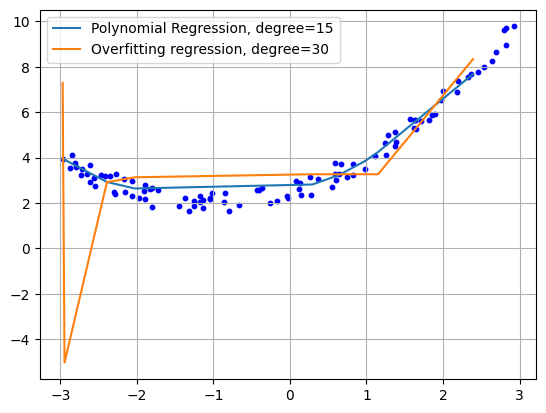

In [27]:
plt.scatter(X, y, c="blue", s=10)
plt.plot(X_new_poly[sorted_idx], poly_predictions[sorted_idx], label="Polynomial Regression, degree=15")
plt.plot(X_new_poly[sorted_idx], poly_predictions_overfit[sorted_idx], label="Overfitting regression, degree=30")
plt.legend()
plt.grid(True)
plt.show()

> As you can see, orange line shows how exessive amount of powers makes the model overfit the data

Great! Basically, now, our linear regression model equation would look like this:
$$
\hat{y} = \theta_0 + \theta_1 x + \theta_2 x^2 + \dots + \theta_n x^n
$$

# Learning Curves

Often, it's hard to determine whether your model _underfits_ or _overfits_ the training set. **Learning Curves** can help you with that.

Learning curves help you to see both training set error and validation set error during the model training process. **SKLearn** provides learning_curve function for this

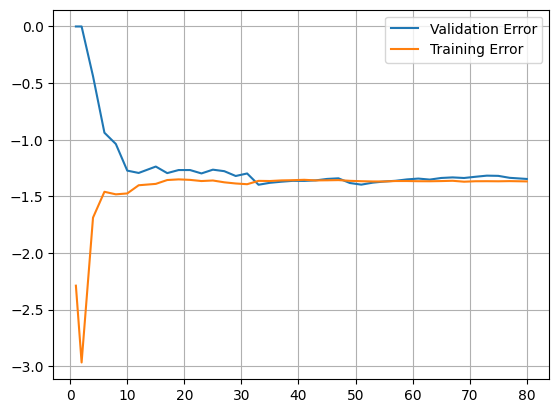

In [28]:
train_sizes, train_scores, valid_scores = learning_curve(
    LinearRegression(), X, y, cv=5,
    scoring="neg_root_mean_squared_error",
    train_sizes=np.linspace(0.01, 1.0, 40) # https://numpy.org/doc/stable/reference/generated/numpy.linspace.html
)

train_errors = train_scores.mean(axis=1)
valid_errors = valid_scores.mean(axis=1)

plt.plot(train_sizes, train_errors, label="Validation Error")
plt.plot(train_sizes, valid_errors, label="Training Error")

plt.legend()
plt.grid(True)
plt.show()

As we can see, both errors reached plateau. And validation error doesn't lower as model gets more training data, and the error is quite large. It means that the model underfitting the training data.

Let's add polynomial features and see how excessive amount of degrees would affect the results.

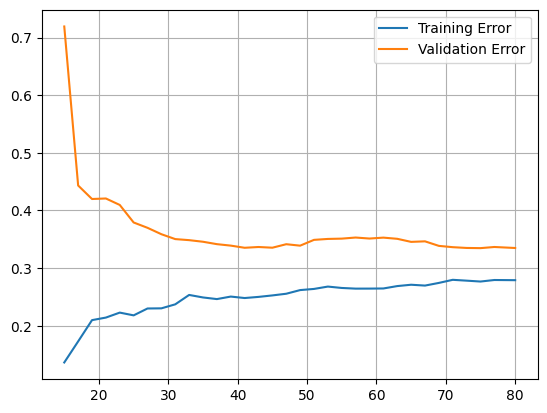

In [29]:
polynomial_regression_pipeline = make_pipeline(
    PolynomialFeatures(degree=10),
    LinearRegression()
)

train_sizes, train_scores, valid_scores = learning_curve(
    polynomial_regression_pipeline, X, y, cv=5,
    scoring="neg_root_mean_squared_error",
    train_sizes=np.linspace(0.01, 1.0, 40) # https://numpy.org/doc/stable/reference/generated/numpy.linspace.html
)

train_errors = -train_scores.mean(axis=1)
valid_errors = -valid_scores.mean(axis=1)

plt.plot(train_sizes[7:], train_errors[7:], label="Training Error")
plt.plot(train_sizes[7:], valid_errors[7:], label="Validation Error")

plt.legend()
plt.grid(True)
plt.show()

But, if we add 10-th degree polynomial model, it is clear that you model slightly overfits the training data. Because the model validation error is larger that a training one. To improve an overfitting model - feed it more training data, until the validation error reaches the training error.

> I didn't get the results from the book. Current plot is typical to normal model. Imagine that there is huge gap between two errors ;)

# Ridge "l2" regularization

Ridge regression is an approach for fining the model for big parameters values. This approach minimizes $\theta$ parameters.

Performing **Ridge Regression closed-form solution**

In [30]:
identity_ridge = np.identity(X_d.shape[1])
identity_ridge[0, 0] = 0

theta_ridge = np.linalg.inv(X_d.T @ X_d + (0.01 * identity_ridge)) @ X_d.T @ y

theta_ridge

array([[3.69466544],
       [0.19347301]])

L2 regularization using **SKLearn Ridge**

In [31]:
ridge_reg = Ridge(alpha=0.1)
ridge_reg.fit(X, y)

ridge_reg.intercept_, ridge_reg.coef_

(array([4.06537769]), array([0.8645233]))

# Lasso "L1" Regularization

Lasso regression is an regularization approach. Lasso tends to eliminate the weights of least important features.

In [32]:
lasso_reg = Lasso(alpha=0.1)
lasso_reg.fit(X, y)

lasso_reg.intercept_, lasso_reg.coef_

(array([4.05849552]), array([0.83300579]))

Also, you can use **SGDRegressor** both using L1 and L2, by setting penalty to "l1" or "l2"

**SKLearn** provides classes for CV searches for Ridge, Lasso and ElasticNet regularizations which running much faster.

# Early stopping

The most easy to understand and effective approach of regularization. Based on the Learning curves.

Here is quick implementation of early stopping

Best validation RMSE: 2.1904037487677477
Best SGDRegressor found at epoch 73


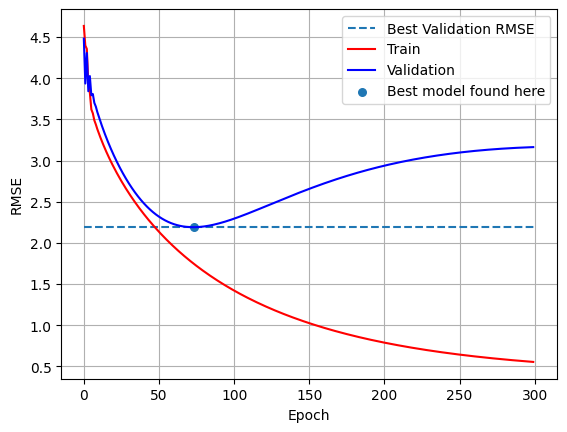

In [33]:
for train_idx, test_idx in ShuffleSplit(n_splits=1, test_size=0.2, random_state=42).split(X, y):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

preprocessing = make_pipeline(
    PolynomialFeatures(degree=130, include_bias=False),
    StandardScaler(),
)

X_train_prep = preprocessing.fit_transform(X_train)
X_test_prep = preprocessing.transform(X_test)

sgd_reg = SGDRegressor(eta0=0.001, random_state=42)
n_epochs = 300

best_valid_rmse = np.float32('inf')
best_sgd = None
found_at_epoch = 0

train_rmse_arr = []
valid_rmse_arr = []
epochs_arr = range(n_epochs)

for epoch in range(n_epochs):
    sgd_reg.partial_fit(X_train_prep, y_train.ravel())
    epoch_valid_predictions = sgd_reg.predict(X_test_prep)
    epoch_train_predictions = sgd_reg.predict(X_train_prep)

    mean_rmse_valid = root_mean_squared_error(y_test, epoch_valid_predictions)
    mean_rmse_train = root_mean_squared_error(y_train, epoch_train_predictions)

    train_rmse_arr.append(mean_rmse_train)
    valid_rmse_arr.append(mean_rmse_valid)

    if mean_rmse_valid < best_valid_rmse:
        best_valid_rmse = mean_rmse_valid
        best_sgd = deepcopy(sgd_reg)
        found_at_epoch = epoch

print(f"Best validation RMSE: {best_valid_rmse}")
print(f"Best SGDRegressor found at epoch {found_at_epoch}")

plt.plot([0, n_epochs], [best_valid_rmse, best_valid_rmse], label="Best Validation RMSE", linestyle="--")
plt.plot(epochs_arr, train_rmse_arr, label="Train", color="red")
plt.plot(epochs_arr, valid_rmse_arr, label="Validation", color="blue")
plt.scatter(found_at_epoch, best_valid_rmse, label="Best model found here", s=30)
plt.legend()
plt.grid(True)
plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.show()

This code shows how early stopping helps find best model. As we can see, after epoch where we found best model, learning curve results start to show that the model overfits the data.

# Logistic Regression

Let's tackle the **Iris** dataset to illustrate work of logistic regression.

Firstly, we need to download the dataset

In [40]:
iris = sk_datasets.load_iris(as_frame=True)

print(f"List of features: {list(iris)}")
print("Data column:")
print(iris.data.head(3))

print(f"\nTarget column")
print(iris.target.head(3))

print(f"\n Target names: {iris.target_names}")

List of features: ['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module']
Data column:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2

Target column
0    0
1    0
2    0
Name: target, dtype: int64

 Target names: ['setosa' 'versicolor' 'virginica']


In [62]:
# These are the dataframes
iris_data = iris.data
iris_target = iris.target

X = (iris_data["petal width (cm)"].values)[:, np.newaxis] # Numpy 1D array transformed to a column vector
y = (iris.target_names[iris_target] == "virginica").astype("int")

for train_idx, test_idx in StratifiedShuffleSplit(n_splits=1, test_size=0.2, train_size=0.8, random_state=42).split(X, y):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

log_reg = LogisticRegression(random_state=42) # Regularization strength is a C parameter
log_reg.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


Now, let's create some artificial petal width data, ranging from 0 to 3, and visualize the model's decision boundary

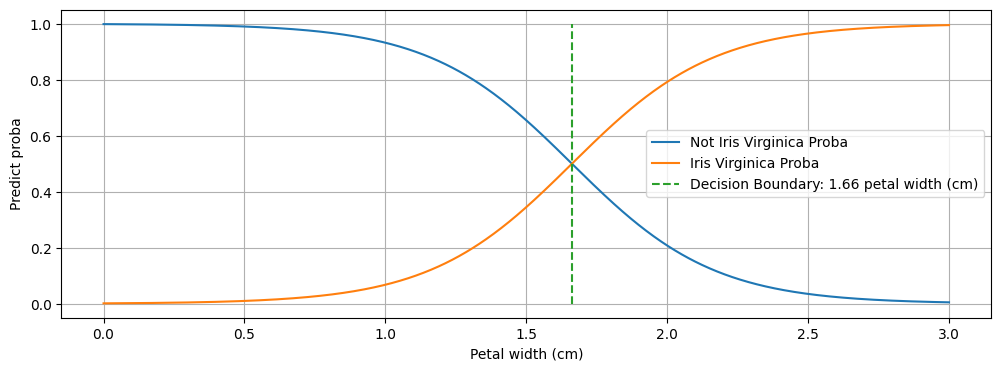

In [92]:
X_new = np.linspace(0, 3, 1000)[:, np.newaxis]
y_proba = log_reg.predict_proba(X_new)
decision_boundary = X_new[y_proba[:, 1] >= 0.5][0, 0]

plt.figure(figsize=(12, 4))

plt.plot(X_new, y_proba[:, 0], label="Not Iris Virginica Proba")
plt.plot(X_new, y_proba[:, 1], label="Iris Virginica Proba")
plt.plot([decision_boundary, decision_boundary], [0, 1], label=f"Decision Boundary: {decision_boundary.round(2)} petal width (cm)", linestyle="--")

plt.grid(True)
plt.xlabel("Petal width (cm)")
plt.ylabel("Predict proba")
plt.legend()
plt.show()

As we can see, our linear model will always return positive class if the `petal width (cm)` attribute is greater than $1.66(366)$.

Mathematically, this value is the solution for linear regression _(or polynomial regression)_ model equation, e.g:
$$
0 = \theta_o + \theta_1 x + \theta_2 x^2
$$

This will give us $\hat{y}=0$. That become $0.5$ after the sigmoid $\sigma$ activation function.

Let's check that $1.66(366)$ is our threshold:

In [94]:
print(f"Decision boundary: {decision_boundary}")
log_reg_predictions = log_reg.predict([[1.5], [1.7]])
print(f"Predictions: {log_reg_predictions.astype(bool)}")

Decision boundary: 1.6636636636636637
Predictions: [False  True]


Yep! That's correct. If our data was linear, our predictions would have non-linear decision boundary _(in this case - quadratic with `degree=2`)_. For example, if our X had linear distribution _(`np.linspace` hello!)_, our predictions would look like this: `[false, false, true, true, false, true, ..., true]`